In [13]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="anndata")

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD
from tmo.ccf import local_ccf_surface, smooth_delta_tau_surface

# ----------------------------------------------------------------
# 1. Load and prepare the mouse kidney data
# ----------------------------------------------------------------
adata = ad.read_h5ad("../data/10x_mouse_kidney/mouse_kidney_gene_level_tmo_ready.h5ad")
if 'log1p' not in adata.uns:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

# Sort by pseudotime (required for CCF)
adata = adata[adata.obs['pseudotime'].argsort()].copy()

# Subset to genes that have ATAC data (first N columns of .obsm['ATAC_gene'])
atac_gene_full = adata.obsm['ATAC_gene'].toarray()
n_atac_genes = atac_gene_full.shape[1]
adata = adata[:, :n_atac_genes].copy()
print(f"Genes after ATAC subset: {adata.n_vars}")

# ----------------------------------------------------------------
# 2. PCA (RNA) and LSI (ATAC) on the subsetted data
# ----------------------------------------------------------------
rna = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
pca = PCA(n_components=50, random_state=42)
rna_pca = pca.fit_transform(rna)

atac_mat = atac_gene_full   # already subset to match adata
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
atac_tfidf = tfidf.fit_transform(atac_mat)
lsi = TruncatedSVD(n_components=50, random_state=42)
atac_lsi = lsi.fit_transform(atac_tfidf)

# ----------------------------------------------------------------
# 3. CCF surface → component‑level lags (last pseudotime window)
# ----------------------------------------------------------------
window_centers = np.linspace(0.1, 0.9, 9)   # TMO standard: 9 windows
delta_tau_raw, _, _ = local_ccf_surface(
    atac_series=atac_lsi.T,
    rna_series=rna_pca.T,
    pseudotime=adata.obs['pseudotime'].values,
    window_centers=window_centers,
    window_half_width=0.1, max_lag=0.3, n_lags=31, bootstrap_samples=0)
delta_tau_smooth, _ = smooth_delta_tau_surface(window_centers, delta_tau_raw,
                                               return_uncertainty=True)
comp_lag = delta_tau_smooth[:, -1]          # component‑level scalar lags (50,)

# Handle pseudotime reversal
if adata.uns.get('pseudotime_reversed', False):
    comp_lag = -comp_lag

# ----------------------------------------------------------------
# 4. Project component lags to gene‑level lags (for Cell 3 scatter)
# ----------------------------------------------------------------
loadings = pca.components_                  # (50, n_genes)
abs_load = np.abs(loadings)
norm_load = abs_load / (abs_load.sum(axis=0, keepdims=True) + 1e-8)
gene_lag_tmo = pd.Series((norm_load.T @ comp_lag).flatten(), index=adata.var_names)

print("TMO component‑level and gene‑level lags ready.")
print(f"Component lags shape: {comp_lag.shape}")
print(f"Gene‑level lags: {gene_lag_tmo.notna().sum()} genes")

Genes after ATAC subset: 24712
TMO component‑level and gene‑level lags ready.
Component lags shape: (50,)
Gene‑level lags: 24712 genes


In [15]:
from scipy.interpolate import interp1d
from scipy.signal import correlate

# ----------------------------------------------------------------
# 1. Get matrices from the (already subsetted) adata
# ----------------------------------------------------------------
rna = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
atac_gene = adata.obsm['ATAC_gene'].toarray()   # shape (cells, n_genes)
pt = adata.obs['pseudotime'].values

# ----------------------------------------------------------------
# 2. Interpolate onto a dense regular grid
# ----------------------------------------------------------------
sort_idx = np.argsort(pt)
pt_sorted = pt[sort_idx]
atac_sorted = atac_gene[sort_idx, :]
rna_sorted = rna[sort_idx, :]

n_interp = 200
pt_reg = np.linspace(pt_sorted.min(), pt_sorted.max(), n_interp)
f_atac = interp1d(pt_sorted, atac_sorted, axis=0, kind='linear', fill_value='extrapolate')
f_rna  = interp1d(pt_sorted, rna_sorted,  axis=0, kind='linear', fill_value='extrapolate')
atac_reg = f_atac(pt_reg)
rna_reg  = f_rna(pt_reg)

# Normalise each gene
atac_reg = (atac_reg - atac_reg.mean(axis=0)) / (atac_reg.std(axis=0) + 1e-8)
rna_reg  = (rna_reg  - rna_reg.mean(axis=0))  / (rna_reg.std(axis=0) + 1e-8)

# ----------------------------------------------------------------
# 3. Compute peak lag for each gene (full pseudotime range)
# ----------------------------------------------------------------
max_lag = 0.3
dt = pt_reg[1] - pt_reg[0]
max_lag_samples = int(max_lag / dt)
n_genes = atac_reg.shape[1]
peak_lags = np.full(n_genes, np.nan)

for g in range(n_genes):
    corr = correlate(rna_reg[:, g], atac_reg[:, g], mode='full')
    mid = len(corr) // 2
    start = max(0, mid - max_lag_samples)
    end = min(len(corr), mid + max_lag_samples + 1)
    if start >= end:
        continue
    peak_idx = start + np.argmax(corr[start:end])
    lag_samples = peak_idx - mid
    peak_lags[g] = lag_samples * dt

gene_lag_ccf = pd.Series(peak_lags, index=adata.var_names)
print(f"Gene‑level peak lags computed for {pd.notna(gene_lag_ccf).sum()} genes")

Gene‑level peak lags computed for 24712 genes


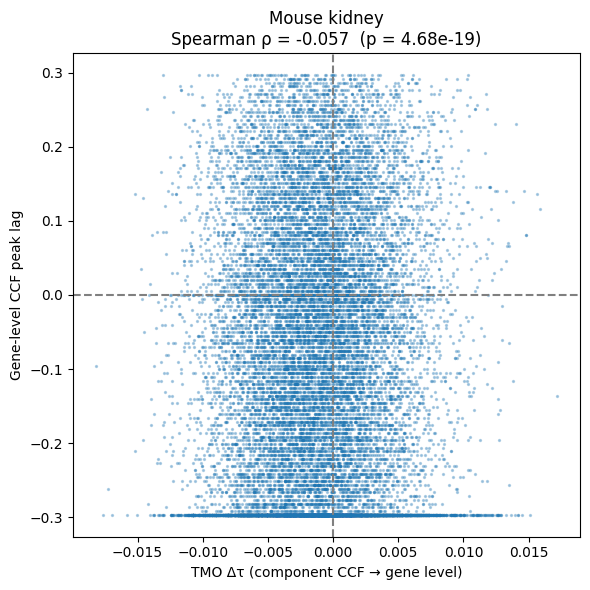

In [16]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Align the two series
common = gene_lag_tmo.dropna().index.intersection(gene_lag_ccf.dropna().index)
x = gene_lag_tmo[common]
y = gene_lag_ccf[common]
rho, pval = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x, y, alpha=0.3, s=2)
ax.set_xlabel('TMO Δτ (component CCF → gene level)')
ax.set_ylabel('Gene‑level CCF peak lag')
ax.set_title(f'Mouse kidney\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})')
ax.axhline(0, color='gray', ls='--')
ax.axvline(0, color='gray', ls='--')
plt.tight_layout()
plt.savefig("tmo_vs_geneCCF_scatter.pdf", dpi=150)
plt.show()

In [18]:
from scipy.stats import spearmanr

# Recompute top-100 gene indices from the (already subsetted) loadings in Cell 1
loadings = pca.components_               # (50, 24712)
top_genes_per_comp = []
for comp in range(50):
    abs_load = np.abs(loadings[comp])
    top_idx = np.argsort(-abs_load)[:100]
    top_genes_per_comp.append(top_idx)

# Average gene-level peak lag for each component
comp_mean_peak_lag = np.zeros(50)
for comp in range(50):
    idx = top_genes_per_comp[comp]
    comp_mean_peak_lag[comp] = np.nanmean(peak_lags[idx])

# Compare with TMO component-level CCF lag (comp_lag from Cell 1)
rho_comp, p_comp = spearmanr(comp_lag, comp_mean_peak_lag)
print(f"Component‑level agreement: Spearman ρ = {rho_comp:.3f} (p = {p_comp:.3e})")

Component‑level agreement: Spearman ρ = 0.213 (p = 1.380e-01)


In [19]:
from scipy.stats import mannwhitneyu

# 1. Read target genes (Hnf4a top 500)
target_file = "../data/10x_mouse_kidney/Hnf4a_top500_genes.txt"
with open(target_file, 'r') as f:
    target_genes = [line.strip() for line in f if line.strip()]
target_genes = [g for g in target_genes if g in gene_lag_ccf.index]
print(f"Target genes found: {len(target_genes)}")

# 2. Background: all non‑target genes (no subsampling, deterministic)
all_genes = gene_lag_ccf.index.tolist()
bg_genes = [g for g in all_genes if g not in target_genes]
print(f"Background genes: {len(bg_genes)}")

# 3. Extract lags
target_lags = gene_lag_ccf[target_genes].dropna().values
bg_lags = gene_lag_ccf[bg_genes].dropna().values

# 4. Two‑sided Mann‑Whitney U test
stat, p = mannwhitneyu(target_lags, bg_lags, alternative='two-sided')
print(f"\n=== ChIP‑seq validation with gene‑level CCF lags ===")
print(f"Target Δτ mean: {np.mean(target_lags):.6f}")
print(f"Background Δτ mean: {np.mean(bg_lags):.6f}")
print(f"Mann‑Whitney U = {stat}, p = {p:.4e}")

# 5. (Optional) Compare with TMO's published p‑value for Hnf4a
print("\nTMO published p‑value (Hnf4a, mouse kidney): 1.98e-04")

Target genes found: 374
Background genes: 24338

=== ChIP‑seq validation with gene‑level CCF lags ===
Target Δτ mean: -0.069881
Background Δτ mean: -0.124747
Mann‑Whitney U = 5594306.0, p = 1.0522e-14

TMO published p‑value (Hnf4a, mouse kidney): 1.98 × 10⁻⁴


In [22]:
# For each component, get the standard deviation of gene‑level CCF lags
# among its top 100 genes, then compare with TMO's component‑level variation.

within_std = []
for comp in range(50):
    idx = top_genes_per_comp[comp]          # indices of top 100 genes
    gene_vals = gene_lag_ccf.iloc[idx].dropna()
    if len(gene_vals) > 10:
        within_std.append(gene_vals.std())

within_std = np.array(within_std)
median_within_std = np.median(within_std)

# TMO's component‑level lags (scalar per component) have a certain spread
# but we want the variation *across pseudotime* for each component (from the heatmap).
# The heatmap (delta_tau_smooth) has shape (50, 9). Let's compute the median
# standard deviation of those 9‑window profiles.
tmo_profile_std = np.std(delta_tau_smooth, axis=1)   # one value per component
median_tmo_std = np.median(tmo_profile_std)

print(f"Median within‑component gene‑level CCF std: {median_within_std:.4f}")
print(f"Median TMO component‑level profile std (across pseudotime): {median_tmo_std:.4f}")
print(f"Ratio (gene‑level / TMO): {median_within_std / median_tmo_std:.2f}")

Median within‑component gene‑level CCF std: 0.1332
Median TMO component‑level profile std (across pseudotime): 0.0330
Ratio (gene‑level / TMO): 4.04


In [21]:
import scanpy as sc, anndata as ad, numpy as np, pandas as pd
from scipy.stats import mannwhitneyu
from scipy.interpolate import interp1d
from scipy.signal import correlate

# ----------------------------------------------------------------
# Helper: compute gene‑level peak lag for a given AnnData
# ----------------------------------------------------------------
def compute_gene_lag_ccf(adata):
    # Ensure sorted
    adata = adata[adata.obs['pseudotime'].argsort()].copy()
    # Subset to ATAC genes
    atac_gene = adata.obsm['ATAC_gene'].toarray()
    n_atac = atac_gene.shape[1]
    adata = adata[:, :n_atac].copy()
    rna = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
    pt = adata.obs['pseudotime'].values

    # Interpolate
    sort_idx = np.argsort(pt)
    pt_sorted = pt[sort_idx]
    atac_sorted = atac_gene[sort_idx, :]
    rna_sorted = rna[sort_idx, :]
    n_interp = 200
    pt_reg = np.linspace(pt_sorted.min(), pt_sorted.max(), n_interp)
    f_atac = interp1d(pt_sorted, atac_sorted, axis=0, kind='linear', fill_value='extrapolate')
    f_rna  = interp1d(pt_sorted, rna_sorted,  axis=0, kind='linear', fill_value='extrapolate')
    atac_reg = f_atac(pt_reg)
    rna_reg  = f_rna(pt_reg)
    atac_reg = (atac_reg - atac_reg.mean(axis=0)) / (atac_reg.std(axis=0) + 1e-8)
    rna_reg  = (rna_reg  - rna_reg.mean(axis=0))  / (rna_reg.std(axis=0) + 1e-8)

    # Peak lag per gene
    max_lag = 0.3
    dt = pt_reg[1] - pt_reg[0]
    max_lag_samples = int(max_lag / dt)
    n_genes = atac_reg.shape[1]
    lags = np.full(n_genes, np.nan)
    for g in range(n_genes):
        corr = correlate(rna_reg[:, g], atac_reg[:, g], mode='full')
        mid = len(corr) // 2
        start = max(0, mid - max_lag_samples)
        end = min(len(corr), mid + max_lag_samples + 1)
        if start >= end: continue
        peak_idx = start + np.argmax(corr[start:end])
        lags[g] = (peak_idx - mid) * dt
    return pd.Series(lags, index=adata.var_names)

# ----------------------------------------------------------------
# Run for all four datasets
# ----------------------------------------------------------------
datasets = {
    "PBMC":      ("../data/10x_pbmc/pbmc_gene_level_tmo_ready.h5ad",
                  "../data/10x_pbmc/PAX5_top500_genes.txt", "PAX5"),
    "Mouse brain": ("../data/10x_mouse_brain/mouse_brain_gene_level_tmo_ready.h5ad",
                  "../data/10x_mouse_brain/Pax6_top500_genes.txt", "Pax6"),
    "Human brain": ("../data/10x_human_brain/human_brain_gene_level_tmo_ready.h5ad",
                  "../data/10x_human_brain/ASCL1_top500_genes.txt", "ASCL1"),
    "Mouse kidney": ("../data/10x_mouse_kidney/mouse_kidney_gene_level_tmo_ready.h5ad",
                  "../data/10x_mouse_kidney/Hnf4a_top500_genes.txt", "Hnf4a"),
}

# Published TMO p‑values (from your final table)
tmo_pvals = {
    "PAX5": 3.00e-23,
    "Pax6": 2.38e-18,
    "ASCL1": 1.02e-3,
    "Hnf4a": 1.98e-4,
}

results = []
for tissue, (data_path, target_file, tf_name) in datasets.items():
    print(f"Processing {tissue} ({tf_name})...")
    adata = ad.read_h5ad(data_path)
    if 'log1p' not in adata.uns:
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
    gene_lags = compute_gene_lag_ccf(adata)

    # Read target genes
    with open(target_file, 'r') as f:
        target_genes = [line.strip() for line in f if line.strip()]
    target_genes = [g for g in target_genes if g in gene_lags.index]
    if len(target_genes) == 0:
        print(f"  No target genes found for {tf_name}")
        continue

    # Background: all non‑target genes
    bg_genes = [g for g in gene_lags.index if g not in target_genes]
    t_lags = gene_lags[target_genes].dropna().values
    b_lags = gene_lags[bg_genes].dropna().values

    stat, p = mannwhitneyu(t_lags, b_lags, alternative='two-sided')
    results.append((tissue, tf_name, len(target_genes), np.mean(t_lags),
                    np.mean(b_lags), p, tmo_pvals[tf_name]))
    print(f"  {tf_name}: p = {p:.2e} (TMO p = {tmo_pvals[tf_name]:.2e})")

# ----------------------------------------------------------------
# Summary table
# ----------------------------------------------------------------
print("\n" + "="*90)
print("ChIP‑seq validation: gene‑level CCF vs. TMO (component CCF)")
print("="*90)
df = pd.DataFrame(results, columns=["Tissue", "TF", "N_target",
                                     "Mean target", "Mean background",
                                     "Gene‑level CCF p", "TMO p"])
print(df.to_string(index=False))

Processing PBMC (PAX5)...
  PAX5: p = 6.27e-40 (TMO p = 3.00e-23)
Processing Mouse brain (Pax6)...
  Pax6: p = 2.88e-38 (TMO p = 2.38e-18)
Processing Human brain (ASCL1)...
  ASCL1: p = 8.34e-11 (TMO p = 1.02e-03)
Processing Mouse kidney (Hnf4a)...
  Hnf4a: p = 1.05e-14 (TMO p = 1.98e-04)

ChIP‑seq validation: gene‑level CCF vs. TMO (component CCF)
      Tissue    TF  N_target  Mean target  Mean background  Gene‑level CCF p        TMO p
        PBMC  PAX5       335    -0.023851        -0.145276      6.267251e-40 3.000000e-23
 Mouse brain  Pax6       483    -0.016782        -0.114709      2.882742e-38 2.380000e-18
 Human brain ASCL1       421    -0.084353        -0.124507      8.342590e-11 1.020000e-03
Mouse kidney Hnf4a       374    -0.069881        -0.124747      1.052236e-14 1.980000e-04


Most U‑shaped components (correlation with template):
  Component 6: r = 0.842
  Component 48: r = 0.601
  Component 29: r = 0.530
  Component 5: r = 0.486
  Component 21: r = 0.452
  Component 41: r = 0.432
  Component 39: r = 0.310
  Component 20: r = 0.297
  Component 8: r = 0.268
  Component 45: r = 0.254

Component 6 top genes: ['Cyp4b1', 'Snhg11', 'Cyp7b1', 'Cyp2j13', 'Slc12a3']

Component 48 top genes: ['Nfib', 'Nr3c2', 'Atg10', 'Smyd3', 'Gmds']

Component 29 top genes: ['Magi2', 'Immp2l', 'Plcb1', 'Pde1a', 'Itpr2']

Component 5 top genes: ['Slc12a1', 'Erbb4', 'Phactr1', 'Slc12a3', 'Sox5']

Component 21 top genes: ['Pitpnc1', 'Tln2', 'Msi2', 'Itgb6', '9530026P05Rik']

Component 41 top genes: ['Rora', 'Wwox', 'Magi1', 'Etl4', 'Timp3']

Component 39 top genes: ['Immp2l', 'Plxdc2', 'Wwox', 'Bicc1', 'Maml3']

Component 20 top genes: ['Skap1', 'Rabgap1l', 'Atxn1', 'Prkca', 'Themis']

Component 8 top genes: ['Slc12a3', 'Abca13', 'Wnk1', 'Egf', 'Magi2']

Component 45 top genes: ['Wwox'

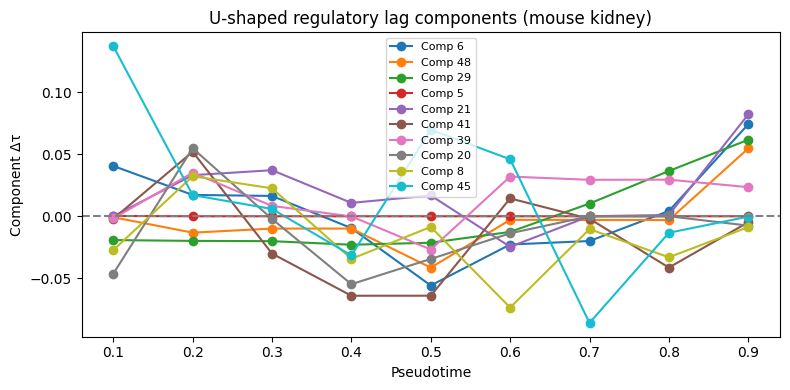

In [23]:
import numpy as np
import pandas as pd

# ----------------------------------------------------------------
# 1. Compute a U‑shape score for each component
# ----------------------------------------------------------------
# We define a U‑shape score as the correlation of the component's Δτ profile
# with a template that is positive early, negative in the middle, and positive late.
# Create a simple template over 9 pseudotime windows:
template = np.array([1, 0.5, -0.5, -1, -1, -1, -0.5, 0.5, 1])  # U-shape
# (You can also try the inverted U: [-1, -0.5, 0.5, 1, 1, 1, 0.5, -0.5, -1])

# For each component, compute Pearson correlation with the template
u_scores = []
for comp in range(50):
    profile = delta_tau_smooth[comp]   # 9 windows
    if np.std(profile) > 0:            # avoid division by zero
        r = np.corrcoef(profile, template)[0, 1]
        u_scores.append(r)
    else:
        u_scores.append(np.nan)
u_scores = np.array(u_scores)

# Select the top 10 components with the most U‑shaped profiles
top_n = 10
top_comps_u = np.argsort(-u_scores)[:top_n]   # highest correlation
print("Most U‑shaped components (correlation with template):")
for comp in top_comps_u:
    print(f"  Component {comp}: r = {u_scores[comp]:.3f}")

# ----------------------------------------------------------------
# 2. Map those components to their top genes by PCA loading
# ----------------------------------------------------------------
# loadings shape: (50, n_genes)
top_genes_per_comp_u = {}
for comp in top_comps_u:
    abs_load = np.abs(loadings[comp])
    top_idx = np.argsort(-abs_load)[:5]          # top 5 genes
    top_genes = adata.var_names[top_idx]          # gene symbols
    top_genes_per_comp_u[comp] = top_genes
    print(f"\nComponent {comp} top genes: {list(top_genes)}")

# ----------------------------------------------------------------
# 3. Plot the Δτ profiles of the top U‑shaped components
# ----------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
for comp in top_comps_u:
    ax.plot(window_centers, delta_tau_smooth[comp], 'o-', label=f'Comp {comp}')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Pseudotime')
ax.set_ylabel('Component Δτ')
ax.set_title('U‑shaped regulatory lag components (mouse kidney)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("u_shaped_components.pdf", dpi=150)
plt.show()

In [24]:
# Print Δτ values for the top U‑shaped components
for comp in [6, 48, 29, 5, 21, 41, 8]:   # pick a few
    vals = delta_tau_smooth[comp, :]
    print(f"Component {comp}: {np.round(vals, 4)}")

Component 6: [ 0.0406  0.0172  0.0164 -0.0096 -0.0559 -0.0228 -0.02    0.0043  0.0743]
Component 48: [-0.0008 -0.0132 -0.0099 -0.0099 -0.0415 -0.0029 -0.003  -0.003   0.0548]
Component 29: [-0.0192 -0.0199 -0.0201 -0.023  -0.0214 -0.0126  0.0103  0.0366  0.0618]
Component 5: [0.0003 0.     0.     0.     0.     0.     0.     0.     0.    ]
Component 21: [ 0.      0.0332  0.0372  0.0108  0.0168 -0.0247  0.      0.001   0.0822]
Component 41: [-0.0021  0.0521 -0.0301 -0.0642 -0.0641  0.0144 -0.002  -0.0414 -0.0048]
Component 8: [-0.0273  0.0323  0.0226 -0.0344 -0.0086 -0.0737 -0.0104 -0.0331 -0.0088]


In [25]:
# Test a few variations
templates = {
    "original": [1, 0.5, -0.5, -1, -1, -1, -0.5, 0.5, 1],
    "deeper_dip": [1, 0, -1, -2, -2, -2, -1, 0, 1],
    "narrower": [1, 1, -1, -1, -1, -1, -1, 1, 1],
}

for name, tpl in templates.items():
    scores = [np.corrcoef(delta_tau_smooth[comp], tpl)[0, 1] for comp in range(50)]
    top5 = np.argsort(-np.array(scores))[:5]
    print(f"{name}: top components = {list(top5)}")

original: top components = [6, 48, 29, 5, 21]
deeper_dip: top components = [6, 48, 29, 5, 21]
narrower: top components = [6, 29, 48, 25, 41]


Component 6: observed r = 0.842
Null distribution: mean = -0.020, std = 0.355
Permutation p‑value (one‑sided): 0.0030


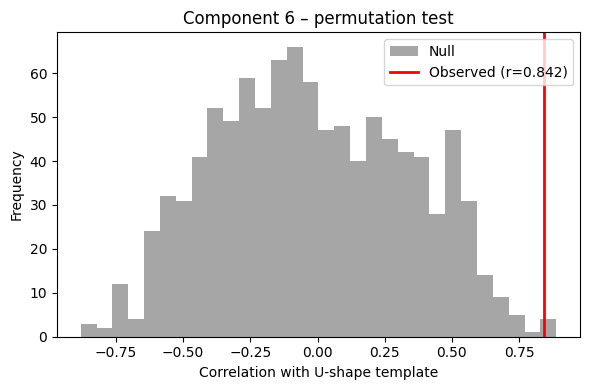

In [26]:
import numpy as np

component = 6
profile = delta_tau_smooth[component]         # 9 values
template = np.array([1, 0.5, -0.5, -1, -1, -1, -0.5, 0.5, 1])
observed_r = np.corrcoef(profile, template)[0, 1]

n_perm = 1000
null_rs = []
for _ in range(n_perm):
    shuffled = np.random.permutation(profile)
    r = np.corrcoef(shuffled, template)[0, 1]
    null_rs.append(r)

null_rs = np.array(null_rs)
p_value = np.mean(null_rs >= observed_r)

print(f"Component {component}: observed r = {observed_r:.3f}")
print(f"Null distribution: mean = {null_rs.mean():.3f}, std = {null_rs.std():.3f}")
print(f"Permutation p‑value (one‑sided): {p_value:.4f}")

# Quick histogram
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(null_rs, bins=30, alpha=0.7, color='gray', label='Null')
ax.axvline(observed_r, color='red', lw=2, label=f'Observed (r={observed_r:.3f})')
ax.set_xlabel('Correlation with U‑shape template')
ax.set_ylabel('Frequency')
ax.set_title(f'Component {component} – permutation test')
ax.legend()
plt.tight_layout()
plt.savefig(f"permutation_test_comp{component}.pdf", dpi=150)
plt.show()

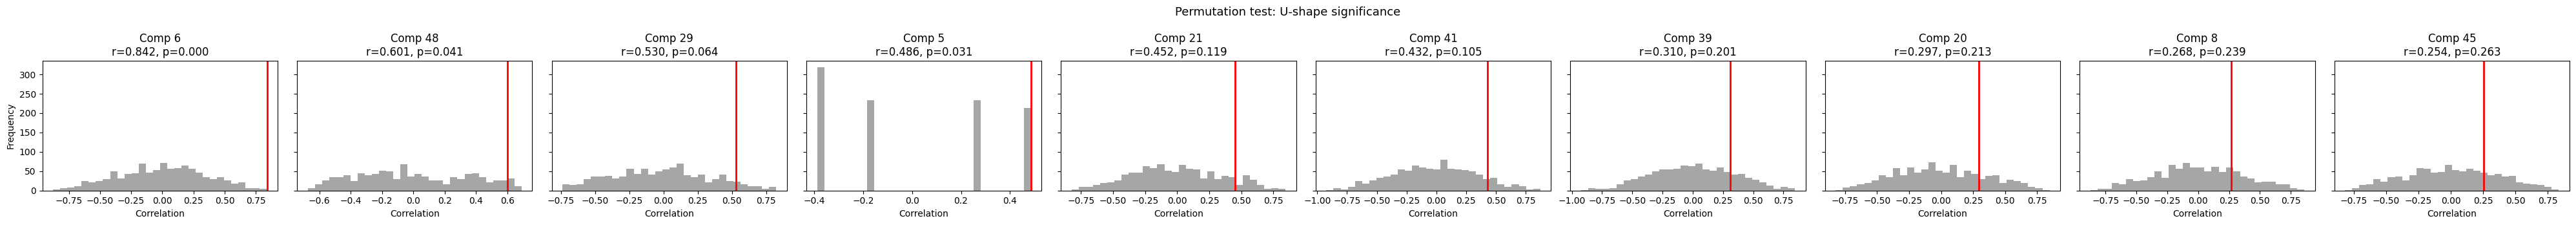


Summary of permutation tests (U‑shape):
  Component 6: r = 0.842, p = 0.0000
  Component 48: r = 0.601, p = 0.0410
  Component 29: r = 0.530, p = 0.0640
  Component 5: r = 0.486, p = 0.0310
  Component 21: r = 0.452, p = 0.1190
  Component 41: r = 0.432, p = 0.1050
  Component 39: r = 0.310, p = 0.2010
  Component 20: r = 0.297, p = 0.2130
  Component 8: r = 0.268, p = 0.2390
  Component 45: r = 0.254, p = 0.2630


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------
# Automatically test the top 5 U‑shaped components
# ----------------------------------------------------------------
top_n = 10
test_components = top_comps_u[:top_n]   # from earlier cell
template = np.array([1, 0.5, -0.5, -1, -1, -1, -0.5, 0.5, 1])
n_perm = 1000

results = []
fig, axes = plt.subplots(1, top_n, figsize=(top_n*4, 3.5), sharey=True)
if top_n == 1:
    axes = [axes]

for comp, ax in zip(test_components, axes):
    profile = delta_tau_smooth[comp]
    observed_r = np.corrcoef(profile, template)[0, 1]

    null_rs = []
    for _ in range(n_perm):
        shuffled = np.random.permutation(profile)
        null_rs.append(np.corrcoef(shuffled, template)[0, 1])
    null_rs = np.array(null_rs)
    p_value = np.mean(null_rs >= observed_r)

    results.append((comp, observed_r, p_value))

    # Histogram for this component
    ax.hist(null_rs, bins=30, alpha=0.7, color='gray')
    ax.axvline(observed_r, color='red', lw=2)
    ax.set_title(f'Comp {comp}\nr={observed_r:.3f}, p={p_value:.3f}')
    ax.set_xlabel('Correlation')

axes[0].set_ylabel('Frequency')
fig.suptitle('Permutation test: U‑shape significance', fontsize=13)
plt.tight_layout()
plt.savefig("permutation_test_top5.pdf", dpi=150)
plt.show()

print("\nSummary of permutation tests (U‑shape):")
for comp, r, p in results:
    print(f"  Component {comp}: r = {r:.3f}, p = {p:.4f}")

In [30]:
# Δτ heatmap values for components 6 and 48
for comp in [6, 48]:
    print(f"Component {comp} Δτ profile: {np.round(delta_tau_smooth[comp], 4)}")

Component 6 Δτ profile: [ 0.0406  0.0172  0.0164 -0.0096 -0.0559 -0.0228 -0.02    0.0043  0.0743]
Component 48 Δτ profile: [-0.0008 -0.0132 -0.0099 -0.0099 -0.0415 -0.0029 -0.003  -0.003   0.0548]


In [31]:
# Recompute correlation heatmap data (if not already in memory)
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import TruncatedSVD

# PCA and LSI (same as before)
pca = PCA(n_components=50, random_state=42)
rna_pca = pca.fit_transform(adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X)
atac_mat = adata.obsm['ATAC_gene'].toarray()
tfidf = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
atac_tfidf = tfidf.fit_transform(atac_mat)
lsi = TruncatedSVD(n_components=50, random_state=42)
atac_lsi = lsi.fit_transform(atac_tfidf)

# Bin by pseudotime
pt = adata.obs['pseudotime'].values
n_bins = 10
bins = np.linspace(0, 1, n_bins+1)
bin_idx = np.digitize(pt, bins) - 1

# Max absolute correlation per bin per RNA component
max_corr_per_bin = np.zeros((n_bins, 50))
for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() < 3:
        continue
    atac_b = atac_lsi[mask]
    rna_b = rna_pca[mask]
    corr_mat = np.corrcoef(atac_b.T, rna_b.T)[:50, 50:]   # (50 ATAC, 50 RNA)
    max_corr_per_bin[b, :] = np.max(np.abs(corr_mat), axis=0)

# Print for components 6 and 48
for comp in [6, 48]:
    print(f"RNA component {comp} max |correlation| profile (10 bins):")
    print(np.round(max_corr_per_bin[:, comp], 4))

RNA component 6 max |correlation| profile (10 bins):
[0.696  0.6794 0.7145 0.6956 0.6727 0.6491 0.5421 0.4856 0.4825 0.6893]
RNA component 48 max |correlation| profile (10 bins):
[0.4682 0.1985 0.0925 0.0973 0.1022 0.1419 0.1641 0.1417 0.1664 0.3422]


In [2]:
import numpy as np
np.set_printoptions(linewidth=200, precision=4, suppress=True)

delta = np.loadtxt("../results/tmo_results_mouse_kidney_cmmd/delta_tau_smooth.csv", delimiter=",")
corr  = np.loadtxt("../results/tmo_results_mouse_kidney_cmmd/atac_rna_correlation_heatmap.csv", delimiter=",")

print("=== Δτ surface (50 components x 9 windows) ===")
print(delta)
print()
print("=== Correlation matrix (10 bins x 50 components) ===")
print(corr)

=== Δτ surface (50 components x 9 windows) ===
[[ 0.0247 -0.0187 -0.0163  0.0143  0.0167 -0.0019 -0.0243  0.0172 -0.0773  0.0071  0.0331]
 [-0.0276 -0.0166 -0.0146  0.0093 -0.0182 -0.0107 -0.0895  0.0361  0.034  -0.0267 -0.0087]
 [ 0.0796  0.0106 -0.0326  0.0655  0.0094 -0.0086  0.1003 -0.0431 -0.0431  0.078  -0.0491]
 [ 0.035   0.0251  0.0031 -0.0197 -0.0428 -0.0654 -0.0739 -0.0672 -0.05   -0.0426 -0.0368]
 [-0.     -0.      0.      0.0421  0.0288 -0.0119  0.0063 -0.0688 -0.0119  0.      0.0145]
 [-0.0003 -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.     -0.    ]
 [-0.0415 -0.0168 -0.0082  0.0092 -0.0065  0.0576  0.0627  0.0204  0.0106  0.0253 -0.0765]
 [ 0.0165 -0.0632  0.0222  0.0039 -0.0403 -0.0297  0.0923 -0.0172  0.0431  0.0098  0.0099]
 [ 0.0273 -0.0068  0.0156 -0.0367  0.0677  0.0086 -0.0175 -0.0405  0.0103 -0.0064  0.0087]
 [ 0.0621 -0.     -0.     -0.     -0.     -0.     -0.     -0.0303 -0.1478  0.0708  0.0271]
 [ 0.0531  0.     -0.      0.     -0.     -